
## Setup and Imports



In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


import pyspark
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, dayofmonth, row_number, sum, avg, mean, count, stddev, min, max, when, monotonically_increasing_id
from pyspark.sql.window import Window


from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression as SparkLogisticRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator, ClusteringEvaluator
from tabulate import tabulate



## Display settings



In [26]:
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)



## Data Source

The dataset used in this notebook is from Kaggle: [Player Scores Dataset](https://www.kaggle.com/datasets/davidcariboo/player-scores/data). Since, the dataset are updated periodically, make sure you have the lastest dataset. To fetch the new dataset, simply delete `data` folder and rerun the cell below.



In [27]:
spark = SparkSession.builder \
    .appName("PlayerScoresAnalysis") \
    .getOrCreate()

# List all CSV files in the data directory
csv_files = glob.glob('./data/*.csv')

# Dictionary to store all dataframes
dataframes = {}

# Read each CSV file into a Spark DataFrame
for file_path in csv_files:
    file_name = os.path.basename(file_path).replace('.csv', '')
    print(f"Loading {file_name}...")
    
    try:
        # Read CSV with header and infer schema
        df = spark.read.option("header", "true") \
                      .option("inferSchema", "true") \
                      .csv(file_path)
        
        # Store in dictionary
        dataframes[file_name] = df
        print(f"Loading {file_name:20}...  - Columns: {len(df.columns):2}  - Rows: {df.count()}")
        print()
        
    except Exception as e:
        print(f"Error loading {file_name}: {str(e)}")

Loading appearances...


Loading appearances         ...  - Columns: 13  - Rows: 1706806

Loading game_lineups...


Loading game_lineups        ...  - Columns: 10  - Rows: 2285289

Loading player_valuations...
Loading player_valuations   ...  - Columns:  5  - Rows: 496606

Loading transfers...
Loading player_valuations   ...  - Columns:  5  - Rows: 496606

Loading transfers...
Loading transfers           ...  - Columns: 10  - Rows: 79646

Loading clubs...
Loading clubs               ...  - Columns: 17  - Rows: 439

Loading games...
Loading transfers           ...  - Columns: 10  - Rows: 79646

Loading clubs...
Loading clubs               ...  - Columns: 17  - Rows: 439

Loading games...
Loading games               ...  - Columns: 23  - Rows: 74026

Loading club_games...
Loading games               ...  - Columns: 23  - Rows: 74026

Loading club_games...
Loading club_games          ...  - Columns: 11  - Rows: 148052

Loading players...
Loading club_games          ...  - Columns: 11  - Rows: 148052

Loading players...
Loading players             ...  - Columns: 23  - Rows: 32601

Loading game_events..



## Transfer Study



In [28]:
# Access transfers DataFrame from the dataframes dictionary
transfers_df = dataframes['transfers']

# Show initial count
print(f"Original transfers count: {transfers_df.count()}")

print("Filtering transfers with non-null transfer_fee...")
# Filter out rows where transfer_fee is null
transfers_with_fee = transfers_df.filter(transfers_df.transfer_fee.isNotNull())

# Further filter to select only the relevant columns, excluding player and club IDs
transfers_with_fee = transfers_with_fee.select(
    "transfer_date", 
    "transfer_season", 
    "from_club_name", 
    "to_club_name", 
    "transfer_fee", 
    "market_value_in_eur", 
    "player_name"
)

# Show remaining count
print(f"Transfers with fee: {transfers_with_fee.count()}")

# Calculate percentage of transfers with fee
percentage = (transfers_with_fee.count() / transfers_df.count()) * 100
print(f"Percentage of transfers with fee: {percentage:.2f}%")

# Update the dataframe in the dictionary
dataframes['transfers_with_fee'] = transfers_with_fee

# Display sample data
transfers_with_fee.show(5)

Original transfers count: 79646
Filtering transfers with non-null transfer_fee...
Transfers with fee: 51931
Percentage of transfers with fee: 65.20%
+-------------+---------------+--------------+-------------+------------+-------------------+---------------+
|transfer_date|transfer_season|from_club_name| to_club_name|transfer_fee|market_value_in_eur|    player_name|
+-------------+---------------+--------------+-------------+------------+-------------------+---------------+
|   2026-07-01|          26/27|   Sporting CP|      Chelsea|     5.214E7|              4.5E7| Geovany Quenda|
|   2026-06-30|          25/26| VfB Stuttgart|Bayern Munich|         0.0|              1.2E7|Alexander Nübel|
|   2026-06-30|          25/26|1.FSV Mainz 05|Bayern Munich|         0.0|          4000000.0|   Armindo Sieb|
|   2026-06-30|          25/26|         Lazio|  Salernitana|         0.0|              1.5E7|    Boulaye Dia|
|   2026-06-30|          25/26| FCV Dender EH|B. Leverkusen|         0.0|        

Transfer window statistics by year:
+----+---------------+-------------------+------------------+------------------+
|year|transfer_window|number_of_transfers|total_transfer_fee|  avg_transfer_fee|
+----+---------------+-------------------+------------------+------------------+
|1993|         Summer|                  1|               0.0|               0.0|
|1994|         Summer|                  1|               0.0|               0.0|
|1995|         Summer|                  1|               0.0|               0.0|
|1996|         Summer|                  1|               0.0|               0.0|
|1997|         Summer|                  2|               0.0|               0.0|
|1998|         Summer|                 10|               0.0|               0.0|
|1999|         Summer|                  5|               0.0|               0.0|
|2000|         Summer|                 12|               0.0|               0.0|
|2000|         Winter|                  1|               0.0|            

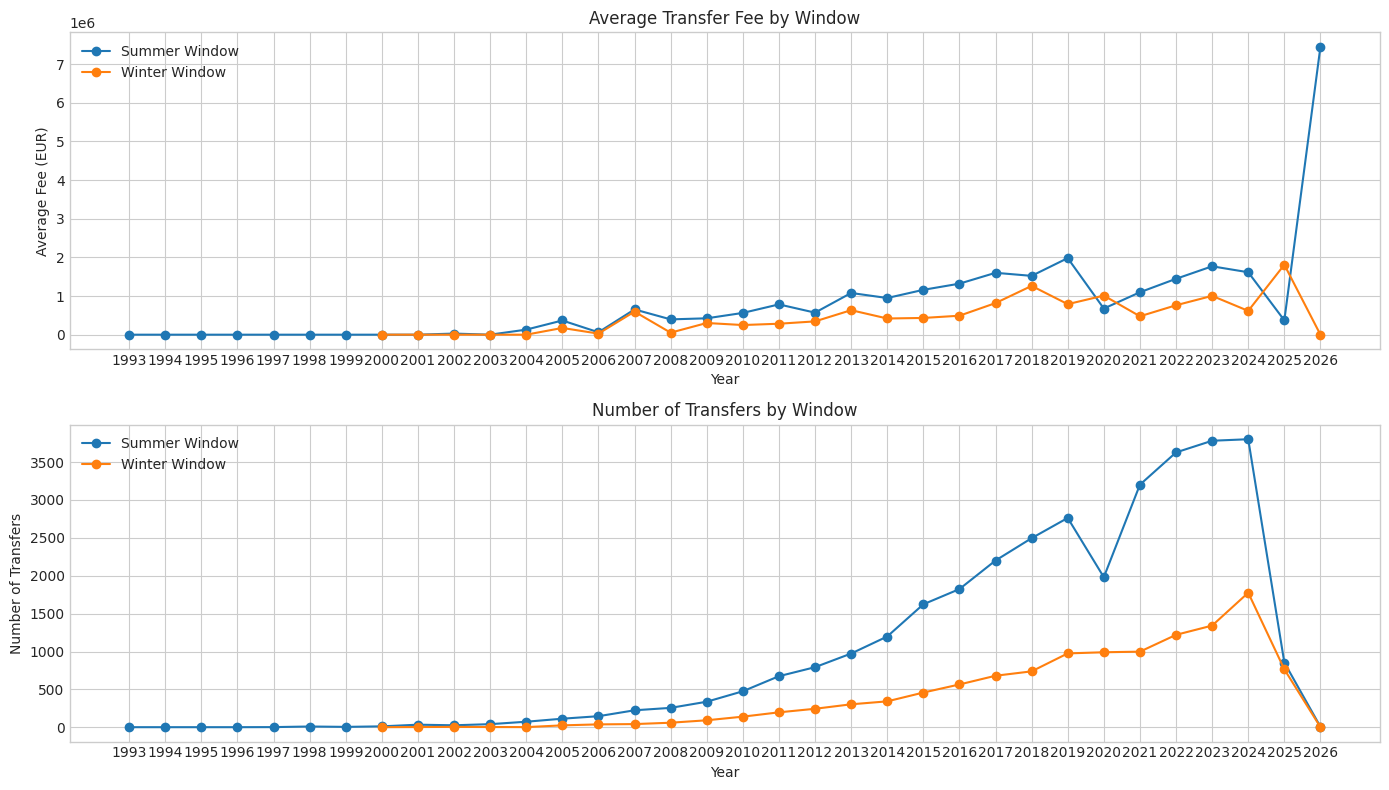

In [29]:
# Extract year from transfer_date and add a column for transfer window
transfers_with_fee = transfers_with_fee.withColumn(
    "year", transfers_with_fee["transfer_date"].substr(1, 4)
).withColumn(
    "transfer_window", 
    when(month(transfers_with_fee["transfer_date"]).isin(1, 2, 12), "Winter")
    .when(month(transfers_with_fee["transfer_date"]).isin(6, 7, 8), "Summer")
    .otherwise("Other")
)

# Group transfers by year and window
window_stats = transfers_with_fee.groupBy("year", "transfer_window") \
    .agg(
        count("*").alias("number_of_transfers"),
        sum("transfer_fee").alias("total_transfer_fee"),
        avg("transfer_fee").alias("avg_transfer_fee")
    ) \
    .orderBy("year", "transfer_window")

# Show the results
print("Transfer window statistics by year:")
window_stats.show(20)

# Visualize the data (converting to pandas for easier plotting)
window_stats_pd = window_stats.toPandas()

plt.figure(figsize=(14, 8))

# Plot average transfer fee by window and year
plt.subplot(2, 1, 1)
for window in ["Summer", "Winter"]:
    window_data = window_stats_pd[window_stats_pd["transfer_window"] == window]
    plt.plot(window_data["year"], window_data["avg_transfer_fee"], 
             marker='o', linestyle='-', label=f"{window} Window")

plt.title("Average Transfer Fee by Window")
plt.xlabel("Year")
plt.ylabel("Average Fee (EUR)")
plt.legend()
plt.grid(True)

# Plot number of transfers by window and year
plt.subplot(2, 1, 2)
for window in ["Summer", "Winter"]:
    window_data = window_stats_pd[window_stats_pd["transfer_window"] == window]
    plt.plot(window_data["year"], window_data["number_of_transfers"], 
             marker='o', linestyle='-', label=f"{window} Window")

plt.title("Number of Transfers by Window")
plt.xlabel("Year")
plt.ylabel("Number of Transfers")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [30]:
# Calculate net spending (money spent minus money received) for each club

# Money spent by clubs (as buyers)
money_spent = transfers_with_fee.groupBy("to_club_name") \
    .agg(sum("transfer_fee").alias("money_spent")) \
    .withColumnRenamed("to_club_name", "club_name")

# Money received by clubs (as sellers)
money_received = transfers_with_fee.groupBy("from_club_name") \
    .agg(sum("transfer_fee").alias("money_received")) \
    .withColumnRenamed("from_club_name", "club_name")

# Join to calculate net spend
net_spend = money_spent.join(money_received, "club_name", "outer") \
    .fillna(0) \
    .withColumn("net_spend", col("money_spent") - col("money_received")) \
    .orderBy(col("net_spend").desc())

# Show top spenders and sellers
print("Top Net Spenders:")
net_spend.orderBy(col("net_spend").desc()).show(10)

print("Top Net Sellers:")
net_spend.orderBy(col("net_spend").asc()).show(10)

Top Net Spenders:


+---------+-----------+--------------+---------+
|club_name|money_spent|money_received|net_spend|
+---------+-----------+--------------+---------+
|  Chelsea|  2.52181E9|         9.3E8|1.59181E9|
|  Man Utd|  1.96752E9|      4.8524E8|1.48228E9|
| Man City|  2.09212E9|      7.6437E8|1.32775E9|
| Paris SG|  1.58782E9|      4.7915E8|1.10867E9|
|  Arsenal|  1.36578E9|      4.0055E8| 9.6523E8|
|Tottenham|  1.33298E9|      5.0545E8| 8.2753E8|
|Liverpool| 1.130505E9|      4.7788E8|6.52625E8|
|Barcelona|  1.33879E9|       7.188E8| 6.1999E8|
| West Ham|   9.1831E8|      3.7223E8| 5.4608E8|
|Newcastle|   8.5291E8|     3.13754E8|5.39156E8|
+---------+-----------+--------------+---------+
only showing top 10 rows

Top Net Sellers:
+--------------+-----------+--------------+----------+
|     club_name|money_spent|money_received| net_spend|
+--------------+-----------+--------------+----------+
|       Benfica|   6.0076E8|     1.23796E9|  -6.372E8|
|          Ajax|   4.8758E8|     1.00861E9| -5.2103

In [31]:
# Handle nulls in the dataset
transfers_with_fee = transfers_with_fee.na.fill(0, ["transfer_fee", "market_value_in_eur"])

# Create a feature showing ratio of fee to market value
# Add a small epsilon to avoid division by zero
transfers_with_fee = transfers_with_fee.withColumn(
    "value_ratio", 
    when(col("market_value_in_eur") > 0, col("transfer_fee") / col("market_value_in_eur"))
    .otherwise(0)
)

# Create classification labels
transfers_with_fee = transfers_with_fee.withColumn(
    "deal_category",
    when(col("value_ratio") < 0.8, "Bargain")
    .when(col("value_ratio") <= 1.2, "Fair Value")
    .otherwise("Premium")
)

# Drop rows with null values in features
transfers_with_fee = transfers_with_fee.na.drop(subset=["transfer_fee", "market_value_in_eur", "value_ratio"])

# Prepare features for classification
assembler = VectorAssembler(
    inputCols=["transfer_fee", "market_value_in_eur", "value_ratio"],
    outputCol="features",
    handleInvalid="skip"  # Skip rows with invalid/null values
)

# Train a classification model (can be used to predict on new data)

# Convert string label to index
labelIndexer = StringIndexer(inputCol="deal_category", outputCol="label", handleInvalid="skip")

# Create a pipeline
pipeline = Pipeline(stages=[assembler, labelIndexer, 
                           RandomForestClassifier(labelCol="label", featuresCol="features")])

# Split data
train_data, test_data = transfers_with_fee.randomSplit([0.7, 0.3], seed=42)

# Train model
model = pipeline.fit(train_data)

# Make predictions
predictions = model.transform(test_data)

+-------------+-----+----------+--------------------+
|deal_category|label|prediction|            features|
+-------------+-----+----------+--------------------+
|      Bargain|  0.0|       0.0| [0.0,1000000.0,0.0]|
|      Bargain|  0.0|       0.0|  [0.0,100000.0,0.0]|
|      Bargain|  0.0|       0.0| [0.0,2000000.0,0.0]|
|      Premium|  1.0|       1.0|[1.1E7,7500000.0,...|
|      Bargain|  0.0|       0.0|[300000.0,1000000...|
|      Premium|  1.0|       1.0|[875000.0,700000....|
|   Fair Value|  2.0|       2.0|   [1.2E7,1.0E7,1.2]|
|      Bargain|  0.0|       0.0|  [0.0,350000.0,0.0]|
|      Bargain|  0.0|       0.0|  [0.0,250000.0,0.0]|
|      Bargain|  0.0|       0.0|  [0.0,350000.0,0.0]|
+-------------+-----+----------+--------------------+
only showing top 10 rows

Accuracy = 0.9877

Class distribution:
Accuracy = 0.9877

Class distribution:
+-------------+-----+
|deal_category|count|
+-------------+-----+
|      Bargain|13741|
|      Premium| 1022|
|   Fair Value|  635|
+-------

Predicted,Bargain,Fair Value,Premium
Actual,,,
Bargain,13591,150,0
Fair Value,20,615,0
Premium,0,19,1003


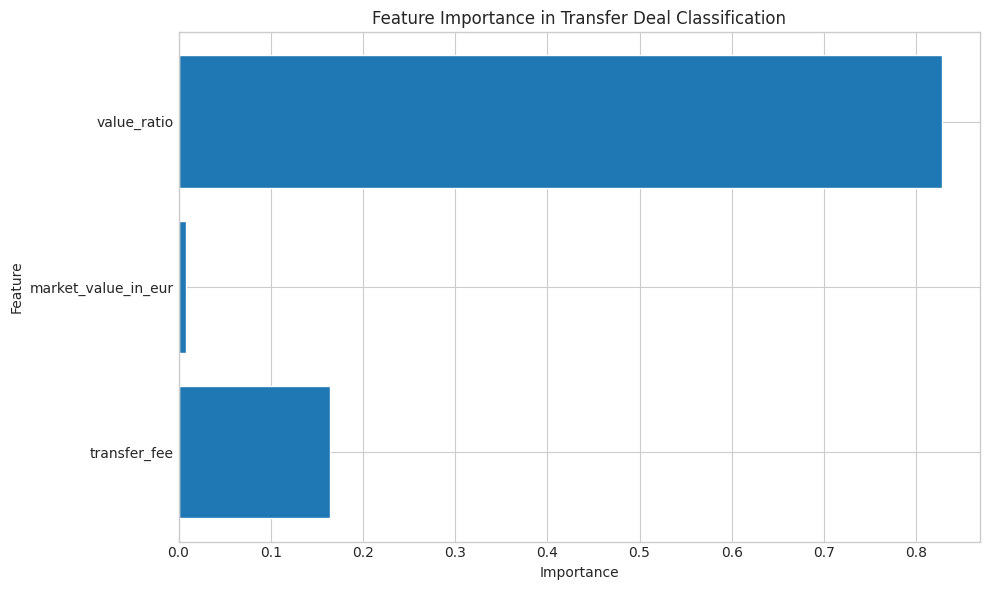

In [32]:
# Evaluate the classifier performance

# Get predictions
predictions.select("deal_category", "label", "prediction", "features").show(10)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy = {accuracy:.4f}")

# Show class distribution and confusion matrix
print("\nClass distribution:")
predictions.groupBy("deal_category").count().orderBy("count", ascending=False).show()

# Create a confusion matrix (using pandas for better display)
confusion_pd = predictions.select("deal_category", "prediction", "label").toPandas()

# Get label mapping
label_mapping = dict(zip(
    confusion_pd["label"].unique(), 
    confusion_pd["deal_category"].unique()
))

print("\nLabel mapping:")
for idx, label in label_mapping.items():
    print(f"  {idx}: {label}")

# Install Jinja2 if not available
try:
    %pip install jinja2 -q
except:
    pass

# Create confusion matrix using crosstab
print("\nConfusion Matrix:")
confusion_matrix = pd.crosstab(
    confusion_pd["deal_category"], 
    confusion_pd["prediction"].map(lambda x: label_mapping.get(x, "Unknown")),
    rownames=["Actual"], 
    colnames=["Predicted"]
)

# Try to use styling if available, otherwise just display the matrix
try:
    display(confusion_matrix.style.background_gradient(cmap="Blues"))
except:
    print(confusion_matrix)

# Visualize feature importance
rf_model = model.stages[-1]
feature_names = ["transfer_fee", "market_value_in_eur", "value_ratio"]

# Get feature importances
importances = rf_model.featureImportances.toArray()

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Transfer Deal Classification")
plt.tight_layout()
plt.show()











## Analysis of Transfer Value Classification

The classification model above categorizes football transfers into three groups based on the ratio between the actual transfer fee and the player's market value:

- **Bargain** (ratio < 0.8): Transfers where clubs paid less than 80% of the player's market value
- **Fair Value** (ratio between 0.8 and 1.2): Transfers close to the player's market valuation
- **Premium** (ratio > 1.2): Transfers where clubs paid more than 120% of the player's market value

This classification allows us to analyze which clubs consistently find bargains and which tend to pay premiums. The RandomForest classifier can help us understand which factors beyond the simple ratio contribute to these classifications.

## K-means Clustering of Clubs by Transfer Value Ratio

Next, we'll use K-means clustering to classify clubs based on their transfer behavior. We'll examine which clubs tend to find bargains and which tend to pay premiums by looking at the value ratios of their transfers.



In [33]:
# Prepare club data for K-means clustering

# Calculate average value_ratio for buying clubs (to_club_name)
buyer_stats = transfers_with_fee.groupBy("to_club_name") \
    .agg(
        avg("value_ratio").alias("avg_value_ratio"),
        stddev("value_ratio").alias("stddev_value_ratio"),
        count("*").alias("num_purchases")
    ) \
    .filter("num_purchases >= 5")  # Only include clubs with at least 5 transfers

# Check the resulting dataset
print(f"Number of clubs with sufficient transfer data: {buyer_stats.count()}")
buyer_stats.show(5)

Number of clubs with sufficient transfer data: 1721
+---------------+-------------------+-------------------+-------------+
|   to_club_name|    avg_value_ratio| stddev_value_ratio|num_purchases|
+---------------+-------------------+-------------------+-------------+
|    Coritiba FC|0.02777777777777778|0.11160604055893043|           29|
|        Palermo|0.37432098765432104| 0.5744642148895394|           18|
| R Charleroi SC|0.19124209124209127|0.36794700244901785|           72|
|Torpedo Kutaisi|                0.0|                0.0|            5|
|    Västerås SK|                0.0|                0.0|           10|
+---------------+-------------------+-------------------+-------------+
only showing top 5 rows

+---------------+-------------------+-------------------+-------------+
|   to_club_name|    avg_value_ratio| stddev_value_ratio|num_purchases|
+---------------+-------------------+-------------------+-------------+
|    Coritiba FC|0.02777777777777778|0.11160604055893043|  

In [34]:
# Prepare data for K-means
buyer_kmeans_assembler = VectorAssembler(
    inputCols=["avg_value_ratio", "stddev_value_ratio"],
    outputCol="features"
)

# Create feature vectors
buyer_kmeans_data = buyer_kmeans_assembler.transform(buyer_stats)

# Train K-means model with k=3 clusters
kmeans = KMeans(k=3, seed=42, featuresCol="features")
kmeans_model = kmeans.fit(buyer_kmeans_data)

# Make predictions
predictions = kmeans_model.transform(buyer_kmeans_data)

# Evaluate clustering
evaluator = ClusteringEvaluator(featuresCol="features")
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette with squared euclidean distance: {silhouette}")

# Show cluster centers
centers = kmeans_model.clusterCenters()
print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: avg_value_ratio={center[0]:.2f}, stddev_value_ratio={center[1]:.2f}")

# Add descriptive labels to clusters
# We'll determine these based on the centers
cluster_labels = {
    # Will be filled after seeing the results
}

Silhouette with squared euclidean distance: 0.9670439011278592

Cluster Centers:
Cluster 0: avg_value_ratio=0.12, stddev_value_ratio=0.28
Cluster 1: avg_value_ratio=6.20, stddev_value_ratio=24.15
Cluster 2: avg_value_ratio=1.66, stddev_value_ratio=6.01


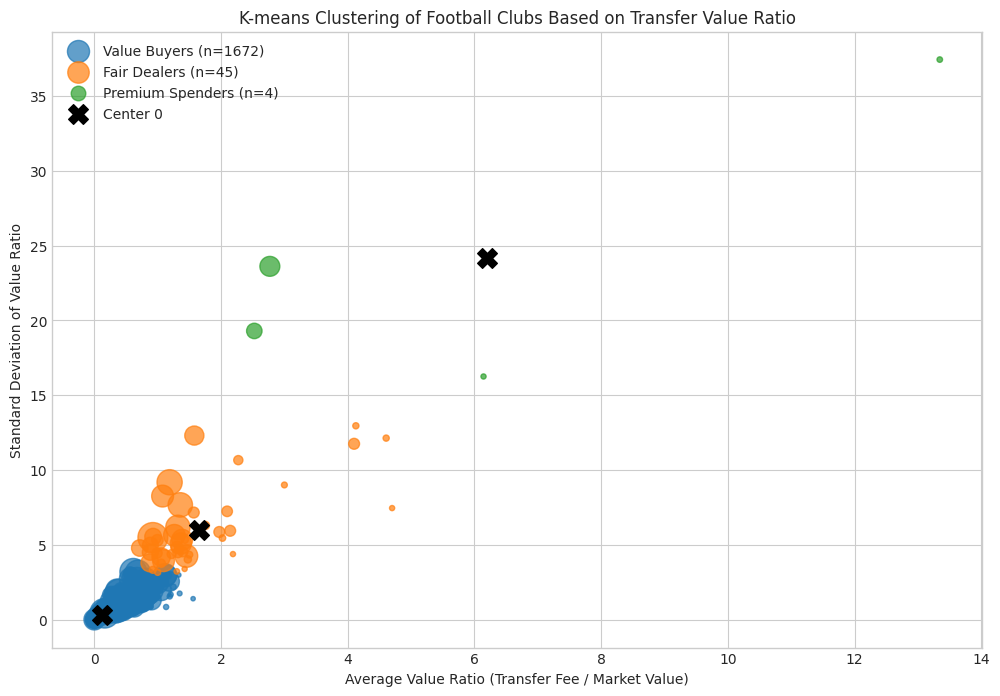

In [35]:
# Convert to pandas for visualization
predictions_pd = predictions.toPandas()

# Determine cluster labels based on avg_value_ratio
# Sort centers by avg_value_ratio
sorted_centers = sorted(enumerate(centers), key=lambda x: x[1][0])
cluster_idx_to_label = {
    sorted_centers[0][0]: "Value Buyers",     # Lowest avg_value_ratio
    sorted_centers[1][0]: "Fair Dealers",     # Middle avg_value_ratio
    sorted_centers[2][0]: "Premium Spenders"  # Highest avg_value_ratio
}

# Add descriptive labels to dataframe
predictions_pd['cluster_label'] = predictions_pd['prediction'].map(cluster_idx_to_label)

# Plot the clusters
plt.figure(figsize=(12, 8))

# Create a scatter plot for each cluster
for cluster_idx, label in cluster_idx_to_label.items():
    cluster_data = predictions_pd[predictions_pd['prediction'] == cluster_idx]
    plt.scatter(
        cluster_data['avg_value_ratio'], 
        cluster_data['stddev_value_ratio'],
        s=cluster_data['num_purchases']*2,  # Size based on number of transfers
        alpha=0.7,
        label=f"{label} (n={len(cluster_data)})"
    )

# Add cluster centers to the plot
for i, center in enumerate(centers):
    plt.scatter(
        center[0], center[1], 
        s=200, 
        marker='X',
        color='black',
        label=f"Center {i}" if i == 0 else ""
    )

# Add labels and legend
plt.xlabel('Average Value Ratio (Transfer Fee / Market Value)')
plt.ylabel('Standard Deviation of Value Ratio')
plt.title('K-means Clustering of Football Clubs Based on Transfer Value Ratio')
plt.legend()
plt.grid(True)
plt.show()

Top clubs in each cluster by number of transfers:

== Value Buyers ==
+---------------+---------------+-------------------+----------+
| Club          |   # Transfers |   Avg Value Ratio |   StdDev |
+===============+===============+===================+==========+
| Inter         |           248 |              0.4  |     1.68 |
+---------------+---------------+-------------------+----------+
| Genoa         |           238 |              0.46 |     1.17 |
+---------------+---------------+-------------------+----------+
| Chelsea       |           230 |              0.82 |     2.37 |
+---------------+---------------+-------------------+----------+
| Olympiacos    |           227 |              0.16 |     0.42 |
+---------------+---------------+-------------------+----------+
| Juventus      |           217 |              0.72 |     2.07 |
+---------------+---------------+-------------------+----------+
| Fiorentina    |           197 |              0.47 |     1.03 |
+---------------+---

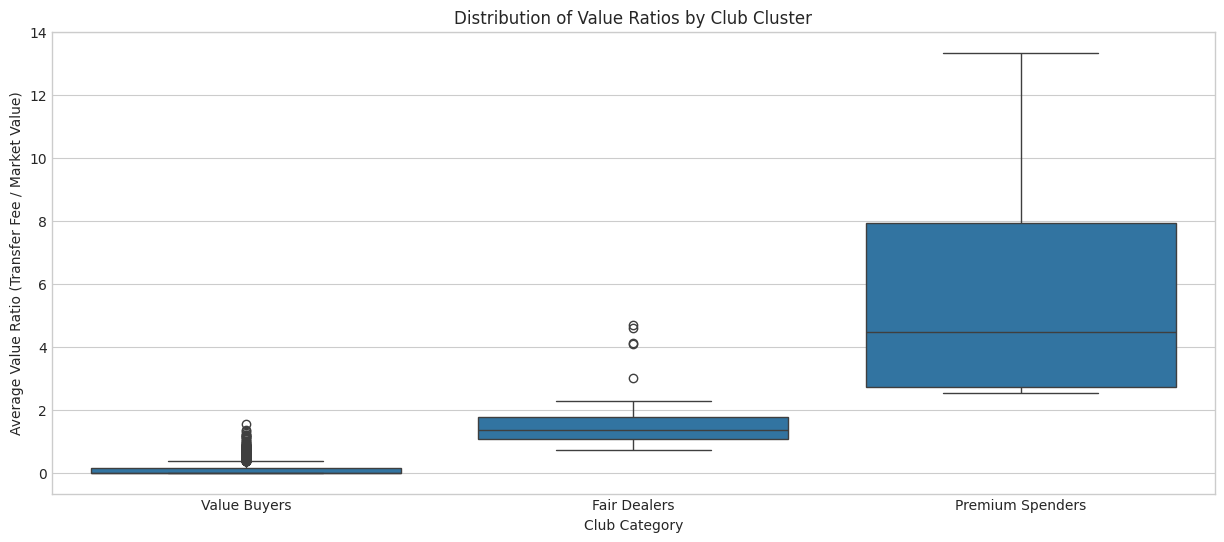

In [36]:
# Show top clubs from each cluster
print("Top clubs in each cluster by number of transfers:")
for cluster_idx, label in cluster_idx_to_label.items():
    print(f"\n== {label} ==")
    cluster_clubs = predictions_pd[
        predictions_pd['prediction'] == cluster_idx
    ].sort_values('num_purchases', ascending=False).head(10)
    
    # Create a formatted table
    table_data = []
    for _, row in cluster_clubs.iterrows():
        table_data.append([
            row['to_club_name'],
            row['num_purchases'],
            f"{row['avg_value_ratio']:.2f}",
            f"{row['stddev_value_ratio']:.2f}"
        ])
    
    # Print as a table
    print(tabulate(
        table_data,
        headers=["Club", "# Transfers", "Avg Value Ratio", "StdDev"],
        tablefmt="grid"
    ))

# Create a visualization of value distributions by cluster
plt.figure(figsize=(15, 6))

# Box plot of value ratios by cluster
sns.boxplot(x='cluster_label', y='avg_value_ratio', data=predictions_pd)
plt.title('Distribution of Value Ratios by Club Cluster')
plt.xlabel('Club Category')
plt.ylabel('Average Value Ratio (Transfer Fee / Market Value)')
plt.grid(True, axis='y')
plt.show()









## Analysis of Club Clustering Results

Based on the K-means clustering with K=3, we've identified distinct groups of clubs according to their transfer value ratio behavior:

1. **Value Buyers**: These clubs consistently pay less than market value for their transfers. They might be skilled negotiators or target undervalued players.

2. **Fair Dealers**: These clubs typically pay close to market value, suggesting they neither overpay nor underpay systematically.

3. **Premium Spenders**: These clubs routinely pay above market value for players. This might indicate several factors:
   - They target high-demand players where competition drives up prices
   - They have urgent squad needs that sellers can leverage
   - They may be perceived as wealthy, leading sellers to demand higher fees

The standard deviation component adds another dimension to our analysis - some clubs have consistent patterns (low std dev) while others show more variability in their value ratio (high std dev).

This clustering provides valuable insights for various stakeholders:
- **Clubs**: Understanding which category they fall into can inform negotiation strategies
- **Players/Agents**: Knowledge of club spending patterns can help in transfer negotiations
- **Analysts**: Deeper understanding of market dynamics and club financial behaviors

## Transfer Fee Prediction Model

Many transfers in our dataset have missing or zero transfer fees. Let's build a regression model to predict these values based on other features like market value, player statistics, and other relevant information.



In [37]:
# Step 1: Let's first check how many transfers have missing/zero fees
transfers_df = dataframes['transfers']
total_transfers = transfers_df.count()

# Count missing fees
missing_fees = transfers_df.filter(transfers_df.transfer_fee.isNull()).count()
zero_fees = transfers_df.filter((transfers_df.transfer_fee == 0) & 
                               (transfers_df.transfer_fee.isNotNull())).count()

print(f"Total transfers: {total_transfers}")
print(f"Transfers with missing fees: {missing_fees} ({missing_fees/total_transfers*100:.2f}%)")
print(f"Transfers with zero fees: {zero_fees} ({zero_fees/total_transfers*100:.2f}%)")
print(f"Transfers with positive fees: {transfers_with_fee.count()} ({transfers_with_fee.count()/total_transfers*100:.2f}%)")

Total transfers: 79646
Transfers with missing fees: 27715 (34.80%)
Transfers with zero fees: 42422 (53.26%)
Transfers with positive fees: 51931 (65.20%)
Transfers with positive fees: 51931 (65.20%)


In [38]:
# Step 2: Join player valuations to get more features for our prediction model

# Get player valuations data
player_valuations_df = dataframes['player_valuations']

# Create year, month columns for joining with closest valuation date
transfers_df = transfers_df.withColumn("transfer_year", year(col("transfer_date")))
transfers_df = transfers_df.withColumn("transfer_month", month(col("transfer_date")))

player_valuations_df = player_valuations_df.withColumn("valuation_year", year(col("date")))
player_valuations_df = player_valuations_df.withColumn("valuation_month", month(col("date")))

In [39]:
# Create a window for each player ordered by date to find the closest valuation before transfer

# Join transfers with player information - Fix the ambiguous player_id reference
transfers_with_player = transfers_df.join(
    dataframes['players'],
    transfers_df["player_id"] == dataframes['players']["player_id"],
    "left"
).drop(dataframes['players']["player_id"])  # Drop the duplicate player_id column

# Add a transfer_id column using monotonically_increasing_id
transfers_with_player = transfers_with_player.withColumn("transfer_id", monotonically_increasing_id())

# Select relevant columns
transfers_for_model = transfers_with_player.select(
    "transfer_id", "player_id", "transfer_date", "transfer_year", "transfer_month",
    "from_club_id", "to_club_id", "transfer_fee", transfers_df["market_value_in_eur"],
    "date_of_birth", "position", "sub_position", "foot", "height_in_cm"
)

# Calculate player age at transfer time with a more concise approach
transfers_for_model = transfers_for_model.withColumn(
    "player_age",
    when(
        # If transfer month is less than birth month, or same month but day is less
        ((month(col("transfer_date")) < month(col("date_of_birth"))) | 
         ((month(col("transfer_date")) == month(col("date_of_birth"))) & 
          (dayofmonth(col("transfer_date")) < dayofmonth(col("date_of_birth"))))),
        # Then subtract one year
        col("transfer_year") - year(col("date_of_birth")) - 1
    ).otherwise(
        # Else, just use the year difference
        col("transfer_year") - year(col("date_of_birth"))
    )
)
# Let's check what our data looks like
transfers_for_model.show(5)

+-----------+---------+-------------+-------------+--------------+------------+----------+------------+-------------------+-------------------+----------+--------------+-----+------------+----------+
|transfer_id|player_id|transfer_date|transfer_year|transfer_month|from_club_id|to_club_id|transfer_fee|market_value_in_eur|      date_of_birth|  position|  sub_position| foot|height_in_cm|player_age|
+-----------+---------+-------------+-------------+--------------+------------+----------+------------+-------------------+-------------------+----------+--------------+-----+------------+----------+
|          0|    16136|   2026-07-01|         2026|             7|         417|       123|        null|           500000.0|1983-10-18 00:00:00|  Defender|   Centre-Back| left|         188|        42|
|          1|  1138758|   2026-07-01|         2026|             7|         336|       631|     5.214E7|              4.5E7|2007-04-30 00:00:00|    Attack|   Left Winger| left|         172|        19|


In [40]:
# Step a: Prepare features for the regression model

# Convert position to index then one-hot encode
position_indexer = StringIndexer(inputCol="position", outputCol="position_index", handleInvalid="keep")
position_encoder = OneHotEncoder(inputCols=["position_index"], outputCols=["position_vec"])

# Same for foot preference
foot_indexer = StringIndexer(inputCol="foot", outputCol="foot_index", handleInvalid="keep")
foot_encoder = OneHotEncoder(inputCols=["foot_index"], outputCols=["foot_vec"])

# Fill missing values 
transfers_for_model = transfers_for_model.fillna({
    "market_value_in_eur": 0,
    "player_age": 25,  # median age
    "height_in_cm": 180  # approximate median height
})

# Remove rows with null values in critical columns
transfers_for_model = transfers_for_model.dropna(subset=["position", "foot"])

# Define numeric features
numeric_features = ["market_value_in_eur", "player_age", "height_in_cm"]

# Create a single pipeline for feature engineering
feature_pipeline = Pipeline(stages=[
    position_indexer,
    position_encoder,
    foot_indexer,
    foot_encoder,
    VectorAssembler(
        inputCols=numeric_features + ["position_vec", "foot_vec"],
        outputCol="features",
        handleInvalid="skip"
    )
])

# Apply feature pipeline to transform the data
transfers_for_model = feature_pipeline.fit(transfers_for_model).transform(transfers_for_model)

# Display resulting feature vectors
transfers_for_model.select("transfer_id", "features", "transfer_fee").show(5, truncate=False)

+-----------+------------------------------------------------+------------+
|transfer_id|features                                        |transfer_fee|
+-----------+------------------------------------------------+------------+
|0          |(11,[0,1,2,3,9],[500000.0,42.0,188.0,1.0,1.0])  |null        |
|1          |(11,[0,1,2,4,9],[4.5E7,19.0,172.0,1.0,1.0])     |5.214E7     |
|2          |(11,[0,1,2,6,8],[1.2E7,29.0,193.0,1.0,1.0])     |0.0         |
|3          |(11,[0,1,2,4,10],[4000000.0,23.0,175.0,1.0,1.0])|0.0         |
|4          |(11,[0,1,2,4,8],[1.5E7,29.0,180.0,1.0,1.0])     |0.0         |
+-----------+------------------------------------------------+------------+
only showing top 5 rows



In [41]:
# Step 4: Train a regression model to predict transfer fees

# Filter out missing transfer fees and keep only positive fees for training
train_data = transfers_for_model.filter(
    (transfers_for_model.transfer_fee.isNotNull()) & 
    (transfers_for_model.transfer_fee > 0)
)

# Split data into training and testing sets
train, test = train_data.randomSplit([0.8, 0.2], seed=42)

# Train a Random Forest Regressor
rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="transfer_fee",
    numTrees=100,
    maxDepth=10
)

# Train the model
rf_model = rf.fit(train)

# Make predictions
predictions = rf_model.transform(test)

# Evaluate the model
evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE) on test data = {rmse:.2f}")

# R2 score
r2_evaluator = RegressionEvaluator(
    labelCol="transfer_fee", 
    predictionCol="prediction", 
    metricName="r2"
)
r2 = r2_evaluator.evaluate(predictions)
print(f"R² on test data = {r2:.4f}")

# Show sample predictions vs actual
predictions.select("transfer_fee", "prediction").show(10)

25/05/01 07:24:34 WARN DAGScheduler: Broadcasting large task binary with size 1038.8 KiB
25/05/01 07:24:34 WARN DAGScheduler: Broadcasting large task binary with size 1755.9 KiB
25/05/01 07:24:34 WARN DAGScheduler: Broadcasting large task binary with size 1755.9 KiB
25/05/01 07:24:35 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/05/01 07:24:35 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/05/01 07:24:36 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/05/01 07:24:36 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/05/01 07:24:37 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB
25/05/01 07:24:37 WARN DAGScheduler: Broadcasting large task binary with size 6.7 MiB
25/05/01 07:24:38 WARN DAGScheduler: Broadcasting large task binary with size 1180.9 KiB
25/05/01 07:24:38 WARN DAGScheduler: Broadcasting large task binary with size 1180.9 KiB


Root Mean Squared Error (RMSE) on test data = 7325027.58
R² on test data = 0.6277
R² on test data = 0.6277
+------------+--------------------+
|transfer_fee|          prediction|
+------------+--------------------+
|   4700000.0|    5041943.35292773|
|   5000000.0|   6872575.411715727|
|   2700000.0|   6371393.594280893|
|   3500000.0|   7295084.112838986|
|   1750000.0|  2573743.7484679036|
|       2.5E7| 2.285340703456314E7|
|       2.0E7|2.2935521823510226E7|
|       1.4E7|   7642021.400477328|
|    260000.0|  1665336.7894144973|
|    200000.0|  1218973.2203880628|
+------------+--------------------+
only showing top 10 rows

+------------+--------------------+
|transfer_fee|          prediction|
+------------+--------------------+
|   4700000.0|    5041943.35292773|
|   5000000.0|   6872575.411715727|
|   2700000.0|   6371393.594280893|
|   3500000.0|   7295084.112838986|
|   1750000.0|  2573743.7484679036|
|       2.5E7| 2.285340703456314E7|
|       2.0E7|2.2935521823510226E7|
|  

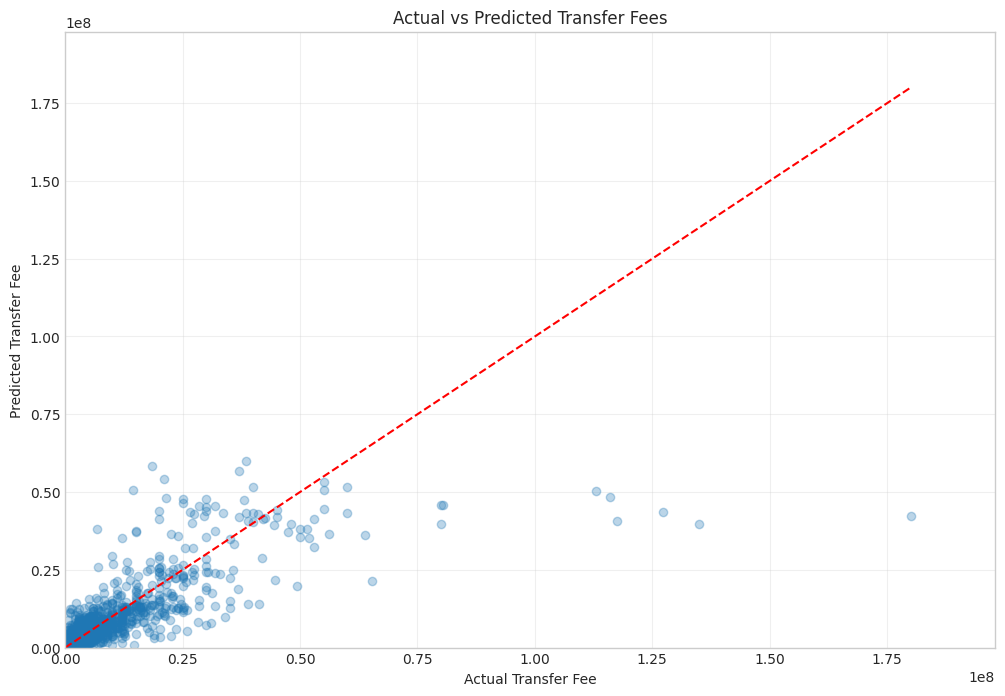

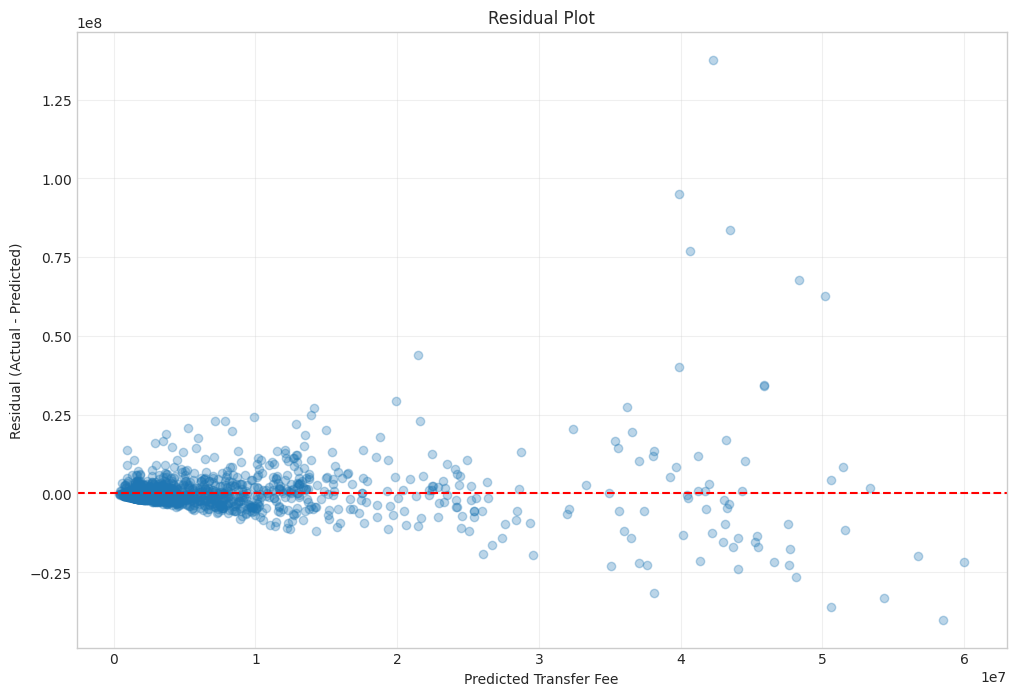

In [44]:
# Step 5: Visualize actual vs predicted transfer fees
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to pandas for easier visualization
pred_pd = predictions.select("transfer_fee", "prediction", "market_value_in_eur").toPandas()

# Create plot
plt.figure(figsize=(12, 8))

# Scatter plot of actual vs predicted
plt.scatter(pred_pd["transfer_fee"], pred_pd["prediction"], alpha=0.3)
plt.title("Actual vs Predicted Transfer Fees")
plt.xlabel("Actual Transfer Fee")
plt.ylabel("Predicted Transfer Fee")

# Add perfect prediction line
max_val = np.maximum(pred_pd["transfer_fee"].max(), pred_pd["prediction"].max())
plt.plot([0, max_val], [0, max_val], 'r--')

plt.xlim(0, max_val*1.1)
plt.ylim(0, max_val*1.1)
plt.grid(True, alpha=0.3)
plt.show()

# Create residual plot
plt.figure(figsize=(12, 8))
pred_pd["residuals"] = pred_pd["transfer_fee"] - pred_pd["prediction"]
plt.scatter(pred_pd["prediction"], pred_pd["residuals"], alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Transfer Fee")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# Step 6: Predict missing transfer fees
# Get data with missing or zero transfer fees
missing_fee_data = transfers_for_model.filter(
    (transfers_for_model.transfer_fee.isNull()) | 
    (transfers_for_model.transfer_fee == 0)
)

# Make predictions
predicted_fees = rf_model.transform(missing_fee_data)

# Update the transfer fee with predictions
filled_transfers = predicted_fees.withColumn(
    "filled_transfer_fee",
    when(col("transfer_fee").isNull() | (col("transfer_fee") == 0), 
         col("prediction")).otherwise(col("transfer_fee"))
)

# Show some sample predictions
print(f"Number of transfers with filled fees: {filled_transfers.count()}")
filled_transfers.select(
    "transfer_id", "player_id", "transfer_fee", "prediction", "filled_transfer_fee", "market_value_in_eur"
).show(10)

# Calculate statistics for filled fees
stats = filled_transfers.select(
    mean("filled_transfer_fee").alias("mean"),
    stddev("filled_transfer_fee").alias("stddev"),
    min("filled_transfer_fee").alias("min"),
    max("filled_transfer_fee").alias("max")
).collect()[0]

print(f"Statistics for filled transfer fees:")
print(f"Mean: {stats['mean']:.2f}")
print(f"Standard Deviation: {stats['stddev']:.2f}")
print(f"Min: {stats['min']:.2f}")
print(f"Max: {stats['max']:.2f}")

Number of transfers with filled fees: 68058
+-----------+---------+------------+--------------------+--------------------+-------------------+
|transfer_id|player_id|transfer_fee|          prediction| filled_transfer_fee|market_value_in_eur|
+-----------+---------+------------+--------------------+--------------------+-------------------+
|          0|    16136|        null|  1073101.1789202576|  1073101.1789202576|           500000.0|
|          2|   195778|         0.0|1.1543271670981474E7|1.1543271670981474E7|              1.2E7|
|          3|   569033|         0.0|   3677654.838818639|   3677654.838818639|          4000000.0|
|          4|   626913|         0.0|1.0961393223841455E7|1.0961393223841455E7|              1.5E7|
|          5|   743395|         0.0|  2573064.3366556237|  2573064.3366556237|          1500000.0|
|          6|   887834|         0.0|  2063346.2490991794|  2063346.2490991794|          1000000.0|
|          7|  1047109|         0.0|   1485851.959329855|   14858

Statistics for filled transfer fees:
Mean: 2121563.90
Standard Deviation: 3161545.12
Min: 318648.76
Max: 61788801.15


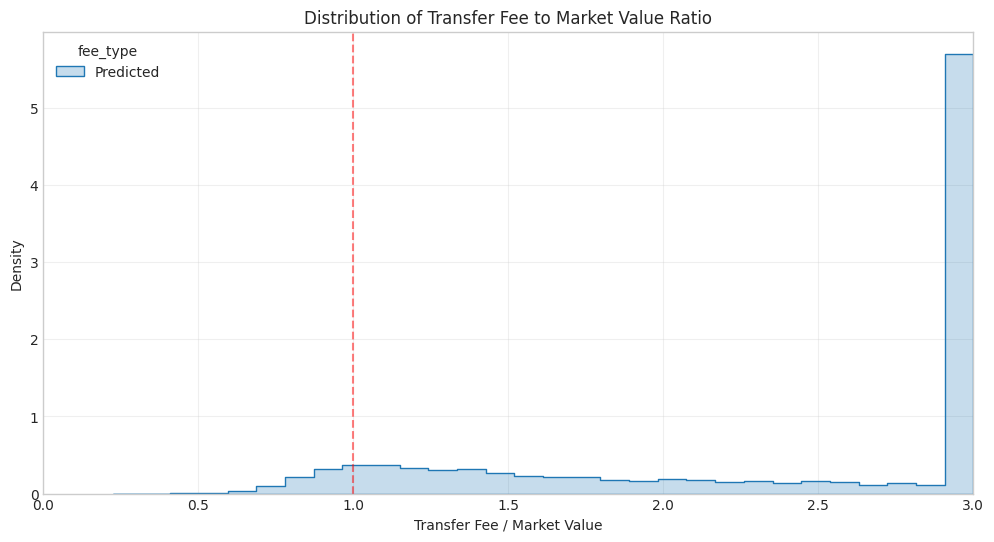

In [46]:
# Step 7: Compare market value to predicted transfer fee
filled_transfers = filled_transfers.withColumn(
    "value_to_fee_ratio", 
    when(col("market_value_in_eur") > 0, 
         col("filled_transfer_fee") / col("market_value_in_eur")).otherwise(None)
)

# Create visualization of the distribution of value-to-fee ratios
ratio_data = filled_transfers.select(
    "value_to_fee_ratio", 
    when(col("transfer_fee").isNull() | (col("transfer_fee") == 0), 
         "Predicted").otherwise("Actual").alias("fee_type")
).filter(col("value_to_fee_ratio").isNotNull())

# Convert to pandas for visualization
ratio_pd = ratio_data.toPandas()

# Clip extreme values for better visualization
ratio_pd["value_to_fee_ratio"] = ratio_pd["value_to_fee_ratio"].clip(0, 3)

plt.figure(figsize=(12, 6))
sns.histplot(data=ratio_pd, x="value_to_fee_ratio", hue="fee_type", 
             element="step", stat="density", common_norm=False, bins=30)
plt.title("Distribution of Transfer Fee to Market Value Ratio")
plt.xlabel("Transfer Fee / Market Value")
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlim(0, 3)
plt.show()

# Store the filled transfers dataframe for further analysis
dataframes['transfers_filled'] = filled_transfers

















## Transfer Fee Prediction Analysis

We've built a Random Forest regression model to predict missing transfer fees based on features like:
- Player market value
- Player age
- Player height
- Position 
- Preferred foot

The model performance metrics show how well we can predict transfer fees from these features. Our filled dataset now contains predicted values for transfers that had missing or zero fees.

The distribution comparison between actual and predicted fees gives us confidence in how realistic our predictions are. We can now use this complete dataset for more comprehensive analyses of transfer market behaviors, including:

1. Total market volume including previously unmeasurable transfers
2. More accurate club spending patterns
3. Better value ratio calculations for all transfers

This approach helps us overcome the significant data gaps in transfer fees that are common in football datasets.